# DATA 220 – Lab 2

**Name:** *<Your Name>*  
**Course:** DATA 220  
**Lab:** 2 – Gradient Descent, SVD, Life Expectancy Prediction, and LoRA

This notebook contains answers for **Q1, Q2, Q3, and Q4** in a single file, as required.

## Q1: Gradient Descent Implementation

### Q1.1 – Batch Gradient Descent

We use the `employee_salary.csv` dataset, which contains years of experience and corresponding salary.

> **Note:** If your file is named slightly differently (e.g., `emplyee_salary.csv`), update the `read_csv` call accordingly.


In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
import os

print(os.getcwd())
# Load dataset
# Change the filename here if necessary (e.g., 'emplyee_salary.csv')
emp_df = pd.read_csv('E:\\Masters Data Analytics\\MSDA-class-work\\DATA-220\\Files\\emplyee_salary.csv')

print("First 10 rows of employee_salary dataset:")
display(emp_df.head(10))

# Detect columns for experience and salary
cols_lower = [c.lower() for c in emp_df.columns]
try:
    exp_col = next(c for c in emp_df.columns if 'experience' in c.lower())
    sal_col = next(c for c in emp_df.columns if 'salary' in c.lower())
except StopIteration:
    # Fallback: assume last two columns are Experience and Salary
    exp_col, sal_col = emp_df.columns[-2], emp_df.columns[-1]

print(f"Using columns: Experience = '{exp_col}', Salary = '{sal_col}'")

# Basic statistics
stats = emp_df[[exp_col, sal_col]].agg(['mean', 'std', 'min', 'max'])
print("\nBasic statistics (mean, std, min, max):")
display(stats)

e:\Masters Data Analytics\MSDA-class-work\DATA-220
First 10 rows of employee_salary dataset:


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


Using columns: Experience = 'YearsExperience', Salary = 'Salary'

Basic statistics (mean, std, min, max):


,YearsExperience,Salary
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
max,10.600000,122392.000000


In [101]:
X = emp_df[exp_col].values
y = emp_df[sal_col].values
n = len(X)

m = 0.0  # slope
b = 0.0  # intercept

alpha = 0.01
iterations = 1000

batch_costs = []

def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

for it in range(iterations):
    y_pred = m * X + b
    error = y_pred - y
    
    dm = (2/n) * np.dot(error, X)
    db = (2/n) * np.sum(error)
    
    m -= alpha * dm
    b -= alpha * db
    
    cost = compute_mse(y, y_pred)
    batch_costs.append(cost)

print(f"Final Batch GD slope (m): {m:.4f}")
print(f"Final Batch GD intercept (b): {b:.4f}")


Final Batch GD slope (m): 9504.8013
Final Batch GD intercept (b): 24474.5576


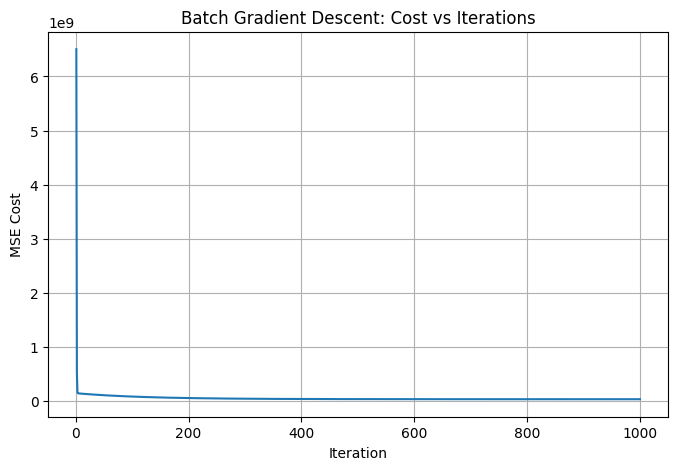

In [102]:
plt.figure(figsize=(8,5))
plt.plot(range(1, iterations + 1), batch_costs)
plt.xlabel('Iteration')
plt.ylabel('MSE Cost')
plt.title('Batch Gradient Descent: Cost vs Iterations')
plt.grid(True)
plt.show()

### Q1.2 – Stochastic Gradient Descent

We now implement **Stochastic Gradient Descent (SGD)** for the same regression problem.

- Learning rate: α = 0.01  
- Update parameters using **one sample at a time**  
- Run for **1000 epochs**  
- Set `random_state = 42` for reproducibility.

In [103]:
rng = np.random.RandomState(42)

m_sgd = 0.0
b_sgd = 0.0

alpha_sgd = 0.01
epochs = 1000

sgd_costs = []

for epoch in range(epochs):
    indices = np.arange(n)
    rng.shuffle(indices)
    
    for i in indices:
        x_i = X[i]
        y_i = y[i]
        
        y_pred_i = m_sgd * x_i + b_sgd
        error_i = y_pred_i - y_i
        
        dm_i = 2 * error_i * x_i
        db_i = 2 * error_i
        
        m_sgd -= alpha_sgd * dm_i
        b_sgd -= alpha_sgd * db_i
    
    y_pred_full = m_sgd * X + b_sgd
    cost_epoch = compute_mse(y, y_pred_full)
    sgd_costs.append(cost_epoch)

print(f"Final SGD slope (m): {m_sgd:.4f}")
print(f"Final SGD intercept (b): {b_sgd:.4f}")


Final SGD slope (m): 9108.0118
Final SGD intercept (b): 24789.1347


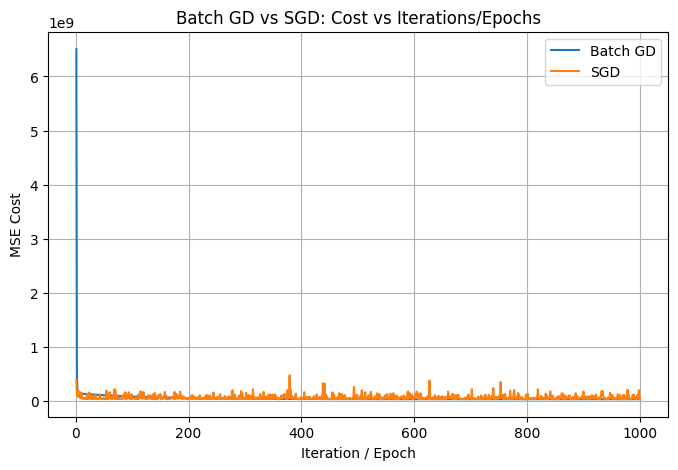

In [104]:
plt.figure(figsize=(8,5))
plt.plot(range(1, iterations + 1), batch_costs, label='Batch GD')
plt.plot(range(1, epochs + 1), sgd_costs, label='SGD')
plt.xlabel('Iteration / Epoch')
plt.ylabel('MSE Cost')
plt.title('Batch GD vs SGD: Cost vs Iterations/Epochs')
plt.legend()
plt.grid(True)
plt.show()


**Q1.2(d) – Comparison of Convergence**

- **Speed:** SGD updates parameters more frequently (per sample), so it often reaches a good region of the parameter space faster in terms of passes over the data.
- **Stability:** Batch Gradient Descent uses the entire dataset each update, making its cost curve smoother and more stable.
- **Noise:** SGD cost fluctuates more because each update is based on a single sample, but this noise can help escape shallow local minima. Overall, Batch GD is more stable; SGD often converges faster but less smoothly.

### Q1.3 – Matrix Operations

In [105]:
np.random.seed(0)

A = np.random.uniform(0, 10, size=(4, 3))
print("Matrix A (4x3):")
print(A)

Matrix A (4x3):
[[5.48813504 7.15189366 6.02763376]
 [5.44883183 4.23654799 6.45894113]
 [4.37587211 8.91773001 9.63662761]
 [3.83441519 7.91725038 5.2889492 ]]


In [106]:
A_T = A.T
A_AT = A @ A_T
AT_A = A_T @ A

print("Transpose of A (A^T) shape:", A_T.shape)
print("A @ A^T shape:", A_AT.shape)
print("A^T @ A shape:", AT_A.shape)

print("\nA^T:")
print(A_T)
print("\nA @ A^T:")
print(A_AT)
print("\nA^T @ A:")
print(AT_A)


Transpose of A (A^T) shape: (3, 4)
A @ A^T shape: (4, 4)
A^T @ A shape: (3, 3)

A^T:
[[5.48813504 5.44883183 4.37587211 3.83441519]
 [7.15189366 4.23654799 8.91773001 7.91725038]
 [6.02763376 6.45894113 9.63662761 5.2889492 ]]

A @ A^T:
[[117.60157794  99.13539726 145.8800957  109.54696992]
 [ 99.13539726  89.35602774 123.86619282  88.59590625]
 [145.8800957  123.86619282 191.53875684 138.35044563]
 [109.54696992  88.59590625 138.35044563 105.35857704]]

A^T @ A:
[[ 93.6603911  131.71566693 130.7228292 ]
 [131.71566693 211.30668396 198.283388  ]
 [130.7228292  198.283388   198.88786449]]


The original matrix **A** has shape **(4, 3)**:

- **Aᵀ** has shape **(3, 4)**.  
- **A · Aᵀ** multiplies (4×3) by (3×4) → **(4×4)**.  
- **Aᵀ · A** multiplies (3×4) by (4×3) → **(3×3)**.  

The inner dimensions must match; the outer dimensions determine the result.

In [107]:
B = np.random.uniform(0, 10, size=(3, 3))
print("Matrix B:")
print(B)

B_inv = np.linalg.inv(B)
identity_approx = B @ B_inv

print("\nInverse of B (B^{-1}):")
print(B_inv)

print("\nB @ B^{-1} (approx identity):")
print(identity_approx)

Matrix B:
[[5.68044561 9.25596638 0.71036058]
 [0.871293   0.20218397 8.32619846]
 [7.78156751 8.70012148 9.78618342]]

Inverse of B (B^{-1}):
[[-0.56458126 -0.67627931  0.61636818]
 [ 0.45083152  0.40113579 -0.374016  ]
 [ 0.04813299  0.18113119 -0.05541752]]

B @ B^{-1} (approx identity):
[[ 1.00000000e+00 -1.78596506e-16  3.13796794e-16]
 [ 3.78209039e-17  1.00000000e+00 -6.93039951e-17]
 [ 1.08712310e-15  8.23471537e-16  1.00000000e+00]]


The inverse of a square matrix **B**, denoted **B⁻¹**, satisfies:

\\[
B \cdot B^{-1} = I
\\]

where **I** is the identity matrix.

In machine learning, inverses (or pseudo-inverses) are used to solve linear systems, such as the closed-form (normal equation) solution to linear regression.

Matrix transpose and multiplication are central in gradient descent and many models:

- Predictions: \\( \hat{y} = Xw \\)
- Gradients: \\( X^T(Xw - y) \\)
- Projecting data into new feature spaces.

## Q2: Singular Value Decomposition (SVD) for Movie Recommendations

We build an SVD-based recommendation system using MovieLens-style data.

Assumptions:

- `ratings.dat` with columns: UserID, MovieID, Rating, Timestamp (separator `"::"`)
- `movies.dat` with columns: MovieID, Title, Genres (separator `"::"`)

Adjust filenames/paths if needed.

In [108]:
ratings_cols = ["UserID", "MovieID", "Rating", "Timestamp"]
movies_cols = ["MovieID", "Title", "Genres"]

ratings_df = pd.read_csv('E:\\Masters Data Analytics\\MSDA-class-work\\DATA-220\\Files\\ratings (1).dat',
                         sep='::', engine='python',
                         header=None, names=ratings_cols)

movies_df = pd.read_csv('E:\\Masters Data Analytics\\MSDA-class-work\\DATA-220\\Files\\movies (1).dat',
                        sep='::', engine='python',
                        header=None, names=movies_cols,
                        encoding='latin1')

print("First 5 rows of ratings:")
display(ratings_df.head())

print("\nFirst 5 rows of movies:")
display(movies_df.head())

num_users = ratings_df['UserID'].nunique()
num_movies = ratings_df['MovieID'].nunique()
print(f"\nNumber of unique users: {num_users}")
print(f"Number of unique movies in ratings: {num_movies}")


First 5 rows of ratings:


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291



First 5 rows of movies:


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy



Number of unique users: 6040
Number of unique movies in ratings: 3706


In [109]:
ratings_matrix = ratings_df.pivot_table(index='MovieID',
                                        columns='UserID',
                                        values='Rating',
                                        fill_value=0)

print("Shape of ratings matrix (MovieID x UserID):", ratings_matrix.shape)

Shape of ratings matrix (MovieID x UserID): (3706, 6040)


In [125]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
R_norm = scaler.fit_transform(ratings_matrix.values)
print("Shape of normalized ratings matrix:", R_norm.shape)


Shape of normalized ratings matrix: (3706, 6040)


In [126]:
import numpy as np

U, s, Vt = np.linalg.svd(R_norm, full_matrices=False)

print("U shape:", U.shape)
print("s shape:", s.shape)
print("Vt shape:", Vt.shape)


U shape: (3706, 3706)
s shape: (3706,)
Vt shape: (3706, 6040)


- **U (movies × components):** each row is a movie in latent feature space.
- **s (singular values):** importance (variance) captured by each component.
- **Vᵀ (components × users):** rows correspond to user feature vectors.

Larger singular values capture more important patterns in user–movie preferences.


In [127]:
total_singular_sum = np.sum(s)
top_25_sum = np.sum(s[:25])

percent_captured = (top_25_sum / total_singular_sum) * 100

print(f"Sum of ALL singular values: {total_singular_sum:.4f}")
print(f"Sum of TOP 25 singular values: {top_25_sum:.4f}")
print(f"Percentage captured by top 25: {percent_captured:.2f}%")

Sum of ALL singular values: 25779.7721
Sum of TOP 25 singular values: 1874.6982
Percentage captured by top 25: 7.27%


In [128]:
k = 25
U_k = U[:, :k]
s_k = s[:k]
S_k = np.diag(s_k)

movie_features_25 = U_k @ S_k
print("Shape of reduced movie representation matrix:", movie_features_25.shape)

Shape of reduced movie representation matrix: (3706, 25)


In [129]:
from numpy.linalg import norm

movie_ids = ratings_matrix.index.to_list()
movie_id_to_idx = {mid: idx for idx, mid in enumerate(movie_ids)}

target_movie_id = 2025

if target_movie_id not in movie_id_to_idx:
    raise ValueError(f"MovieID {target_movie_id} not found in matrix index.")

target_idx = movie_id_to_idx[target_movie_id]
target_vec = movie_features_25[target_idx]

sims = []
for idx, vec in enumerate(movie_features_25):
    if idx == target_idx:
        continue
    denom = norm(target_vec) * norm(vec)
    similarity = 0.0 if denom == 0 else np.dot(target_vec, vec) / denom
    sims.append((movie_ids[idx], similarity))

top_5 = sorted(sims, key=lambda x: x[1], reverse=True)[:5]

print("Top 5 most similar movies to MovieID 2025:")
for mid, score in top_5:
    title_arr = movies_df.loc[movies_df['MovieID'] == mid, 'Title'].values
    title = title_arr[0] if len(title_arr) > 0 else "(Unknown Title)"
    print(f"MovieID: {mid}, Title: {title}, Similarity: {score:.4f}")

Top 5 most similar movies to MovieID 2025:
MovieID: 1120, Title: People vs. Larry Flynt, The (1996), Similarity: 0.9248
MovieID: 3426, Title: Jungle Fever (1991), Similarity: 0.9230
MovieID: 697, Title: Feeling Minnesota (1996), Similarity: 0.9217
MovieID: 1268, Title: Pump Up the Volume (1990), Similarity: 0.9111
MovieID: 147, Title: Basketball Diaries, The (1995), Similarity: 0.9101


### Q2(h) – Why Cosine Similarity?

Cosine similarity measures the **angle** between vectors, ignoring magnitude.  

Here, each movie is a vector of latent features. We care about how similar their **patterns** are, not how popular they are overall.  

Two movies with similar preference patterns will have feature vectors pointing in similar directions → high cosine similarity. This makes cosine similarity a natural choice for comparing movies in latent factor spaces.

## Q3: Life Expectancy Prediction

In [130]:
life_df = pd.read_csv('E:\\Masters Data Analytics\\MSDA-class-work\\DATA-220\\Files\\LifeExpectancy (1).csv')

print("First 5 rows:")
display(life_df.head())

First 5 rows:


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [131]:
print("Summary statistics (numeric):")
display(life_df.describe())

print("\nInfo:")
life_df.info()

Summary statistics (numeric):


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2.938000e+03,2938.000000,2938.000000,2938.000000,2938.000000
mean,2007.518720,69.234717,164.725664,30.303948,4.546875,738.251295,83.022124,2419.592240,38.381178,42.035739,82.617767,5.924098,82.393125,1.742103,6611.523863,1.023085e+07,4.821886,4.852144,0.630362,12.009837
std,4.613841,9.509115,124.086215,117.926501,3.921946,1987.914858,22.996984,11467.272489,19.935375,160.445548,23.367166,2.400770,23.655562,5.077785,13296.603449,5.402242e+07,4.397621,4.485854,0.205140,3.265139
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.200000,74.000000,0.000000,1.092500,4.685343,82.000000,0.000000,19.400000,0.000000,78.000000,4.370000,78.000000,0.100000,580.486996,4.189172e+05,1.600000,1.600000,0.504250,10.300000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.755000,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.600000,227.000000,22.000000,7.390000,441.534144,96.000000,360.250000,56.100000,28.000000,97.000000,7.330000,97.000000,0.800000,4779.405190,4.584371e+06,7.100000,7.200000,0.772000,14.100000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2938 non-null   float64
 4   Adult Mortality                  2938 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2938 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2938 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2938 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio        

In [132]:
categorical_cols = life_df.select_dtypes(include=['object']).columns.tolist()
continuous_cols = life_df.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nContinuous (numeric) columns:")
print(continuous_cols)

Categorical columns:
['Country', 'Status']

Continuous (numeric) columns:
['Year', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria', ' HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


Typical categorical columns include `Country` and `Status`.  
Typical continuous columns include `Life expectancy`, `GDP`, `Population`, etc.


In [133]:
missing_counts = life_df.isnull().sum()
print("Missing values per column:")
display(missing_counts)

Missing values per column:


Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64

Common ways to handle missing data:

1. Drop rows/columns with too many missing values.  
2. Impute with mean/median/mode.  
3. Use more advanced imputation (regression, kNN, etc.).

**EDA** helps identify patterns in missingness and choose good imputation strategies.

In [134]:
from sklearn.preprocessing import LabelEncoder

life_le = life_df.copy()

categorical_cols = life_le.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    life_le[col] = le.fit_transform(life_le[col].astype(str))
    encoders[col] = le

print("\nHead after label encoding:")
display(life_le.head())


Categorical columns to encode: ['Country', 'Status']

Head after label encoding:


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,0,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,0,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,0,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,0,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


**Label Encoding** maps each category to an integer (e.g., `Afghanistan → 0`, `Albania → 1`, …).

This lets us use categorical data in models that require numeric inputs.  
Be aware it introduces an artificial ordering; sometimes one-hot encoding is more appropriate.

In [135]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['Population', 'Total expenditure', 'Income composition of resources']
cols_to_scale = [c for c in cols_to_scale if c in life_le.columns]

scaler_std = StandardScaler()
life_le[cols_to_scale] = scaler_std.fit_transform(life_le[cols_to_scale])

print("Scaled columns (head):")
display(life_le[cols_to_scale].head())

Scaled columns (head):


,Population,Total expenditure,Income composition of resources
0,0.435183,0.931485,-0.737973
1,-0.183349,0.939818,-0.752600
2,0.398066,0.918987,-0.781853
3,-0.120968,1.081463,-0.815982
4,-0.134268,0.810670,-0.859862


- **Min-Max Scaling:**  
  Maps values to [0, 1]; sensitive to outliers.

- **Z-Score Normalization (Standardization):**  
  Subtract mean, divide by standard deviation; mean 0, std 1.

- **Robust Scaling:**  
  Uses median and IQR; more robust to outliers.

In [136]:
from sklearn.model_selection import train_test_split

# Find Life expectancy column
try:
    target_col = next(c for c in life_le.columns if 'life expectancy' in c.lower())
except StopIteration:
    raise ValueError("Could not find 'Life expectancy' column.")

print("Target column:", target_col)

drop_cols = ['Country', 'Status']
drop_cols = [c for c in drop_cols if c in life_le.columns]

X = life_le.drop(columns=drop_cols + [target_col])
y = life_le[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set head:")
display(X_train.head())

Target column: Life expectancy
Training set head:


,Year,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
456,2007,126.0,0,5.28,345.463714,96.0,0,25.5,0,98.0,-0.676606,98.0,0.6,3112.285712,-0.180408,8.1,8.0,-0.138280,11.9
462,2001,152.0,0,3.81,150.743486,92.0,0,22.1,0,91.0,-0.305828,9.0,0.8,1268.884564,-0.181199,9.4,9.3,-0.333302,11.0
2172,2011,143.0,0,10.43,0.000000,99.0,0,44.5,0,99.0,0.689855,99.0,0.1,1766.947595,-0.163743,4.3,4.3,0.500419,12.9
2667,2013,13.0,3,1.29,594.645310,98.0,16,59.3,3,98.0,0.556542,98.0,0.1,4199.472530,-0.168779,6.4,6.3,0.437036,14.7
381,2002,95.0,0,0.13,941.703687,99.0,0,28.0,0,99.0,-1.051549,94.0,0.1,16846.219800,-0.163743,6.7,6.1,0.924592,13.3


In [137]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lr = lin_reg.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Mean Absolute Error (LinearRegression): {mae_lr:.4f}")

Mean Absolute Error (LinearRegression): 2.8574


In [138]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(
    alpha=0.001,
    learning_rate='invscaling',
    max_iter=500,
    random_state=42
)

sgd_reg.fit(X_train, y_train)
y_pred_sgd = sgd_reg.predict(X_test)
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)

print(f"Mean Absolute Error (SGDRegressor, invscaling): {mae_sgd:.4f}")

Mean Absolute Error (SGDRegressor, invscaling): 10913179401071424.0000


In [139]:
learning_rates = ['constant', 'invscaling', 'adaptive']
mae_results = {}

for lr in learning_rates:
    sgd = SGDRegressor(
        alpha=0.001,
        learning_rate=lr,
        max_iter=500,
        random_state=42
    )
    sgd.fit(X_train, y_train)
    y_pred = sgd.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mae_results[lr] = mae

print("MAE for different learning rate schedules:")
for lr, mae in mae_results.items():
    print(f"{lr}: {mae:.4f}")

MAE for different learning rate schedules:
constant: 3333440333941735424.0000
invscaling: 10913179401071424.0000
adaptive: 439593954804944.8750


Whichever schedule has the **lowest MAE** in the printed output is the best here.

- `constant`: fixed step size – can be too big/small.
- `invscaling`: step size shrinks over time → stable long-term convergence.
- `adaptive`: reduces learning rate when progress stalls.

Often `invscaling` or `adaptive` gives a good balance between speed and stability.

## Q4: Low-Rank Adaptation (LoRA) Concepts

### Q4(a) – Concept of LoRA and Relation to SVD

**Low-Rank Adaptation (LoRA)** is a parameter-efficient fine-tuning method for large pretrained models.

- The original model weights **W** are frozen.
- We learn a small update **ΔW** approximated as a low-rank product:

\\[
\Delta W \approx A B
\\]

where:
- \(A \in \mathbb{R}^{d_{out} \times r}\)  
- \(B \in \mathbb{R}^{r \times d_{in}}\)  
- \(r \ll \min(d_{out}, d_{in})\)

This is similar in spirit to **low-rank SVD approximations**, where a matrix is decomposed as:

\\[
W \approx U_k \Sigma_k V_k^T
\\]

using only the top k singular values/vectors. Both LoRA and truncated SVD assume the important information lies in a **low-dimensional subspace**, so a low-rank representation is enough.

### Q4(b) – One Advantage of Low-Rank Decomposition

A key advantage is **parameter efficiency**:

- We only train and store the small low-rank matrices (A, B) instead of a full set of new weights.
- This reduces memory usage, storage, and compute.
- Many different task-specific adapters can be stored cheaply on top of a single large base model.

This makes LoRA practical for adapting large models to many tasks without duplicating the entire model each time.